In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
import ruptures as rpt
from pipeline import *

In [2]:

binance = Binance().data

df = Reddit().data
df['datetime'] = pd.to_datetime(df['utc'], unit='s')

df = df.sort_values('datetime')

df['hour'] = df['datetime'].dt.floor('h')
mod_list = ['42points', 'Jools1802', 'GoodShibe', 'jimjunkdude', 'FloodgatesBot', 'RepostSleuthBot', 'AutoModerator']

df["is_moderator"] = df["from"].isin(mod_list)

df["to_moderator"] = df["to"].isin(mod_list)

df[df['is_moderator'] == 1]['from'].value_counts()

df.head()


,from,to,time,utc,post.id,comment.id,parent.id,from_moderator,to_moderator,datetime,hour,is_moderator
0,Professional_Feed478,Professional_Feed478,2020-12-01 02:05:52,1606784752,k4a18g,k4a18g,k4a18g,False,False,2020-12-01 01:05:52,2020-12-01 01:00:00,False
1,Sporklin,Professional_Feed478,2020-12-01 02:24:55,1606785895,k4a18g,ge7onzo,t3_k4a18g,False,False,2020-12-01 01:24:55,2020-12-01 01:00:00,False
2,shibe5,Professional_Feed478,2020-12-01 02:44:12,1606787052,k4a18g,ge7qspw,t3_k4a18g,False,False,2020-12-01 01:44:12,2020-12-01 01:00:00,False
3,HubertHamster,HubertHamster,2020-12-01 03:19:57,1606789197,k4bdlt,k4bdlt,k4bdlt,False,False,2020-12-01 02:19:57,2020-12-01 02:00:00,False
4,AutoModerator,HubertHamster,2020-12-01 03:19:58,1606789198,k4bdlt,ge7usya,t3_k4bdlt,True,False,2020-12-01 02:19:58,2020-12-01 02:00:00,True


In [3]:

with open('graph.pkl', 'rb') as f:
    G = pickle.load(f)

In [4]:

deg_cent = load_pickle('top_degrees.pkl')
bet_cent = load_pickle('top_betweeness.pkl')

# show top users
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

In [5]:

# PyTorch object with edges and node degree
pyg_graph, node_mapping = networkx_to_pyg(G)
print(f"PyG Graph: {pyg_graph}")

PyG Graph: Data(x=[389931, 1], edge_index=[2, 2306266], num_nodes=389931)


In [8]:
import torch.nn as nn
from torch_geometric.nn import GCNConv
import torch.optim as optim
from torch_geometric.utils import negative_sampling

# We need the edges to tell the model what a "real" connection looks like
edge_index = pyg_graph.edge_index
class GCN(nn.Module):    # graph convolutional network, each layer aggregates information from neighbors
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu() # first layer with ReLU activation
        x = self.conv2(x, edge_index) # second layer (output)
        return x

# Create model and optimizer
model = GCN(in_channels=pyg_graph.x.shape[1], # each layer aggregates information from neighbors, so input is node feature dimension (degree)
            hidden_channels=64, 
            out_channels=32)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()


In [9]:
from torch_geometric.transforms import RandomLinkSplit

# 1. Split data: 80% for training, 20% for testing the 'Link Prediction'
transform = RandomLinkSplit(num_val=0.0, num_test=0.2, is_undirected=True, add_negative_train_samples=False)
train_data, val_data, test_data = transform(pyg_graph)

# 2. Update the training loop to use train_data.edge_label_index
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    
    # Use ONLY the training edges for message passing
    z = model(train_data.x, train_data.edge_index)
    
    # Predict on the 'label' edges (the ones we want to check)
    pos_edge_index = train_data.edge_label_index
    pos_out = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=-1)
    
    # Negative sampling
    neg_edge_index = negative_sampling(train_data.edge_index, num_nodes=train_data.num_nodes)
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    
    # Loss calculation (as you had it)
    pos_loss = -torch.log(torch.sigmoid(pos_out) + 1e-15).mean()
    neg_loss = -torch.log(1 - torch.sigmoid(neg_out) + 1e-15).mean()
    loss = pos_loss + neg_loss
    
    loss.backward()
    optimizer.step()

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate_link_prediction(data):
    model.eval()
    
    # 1. Get embeddings using the message-passing edges (edge_index)
    z = model(data.x, data.edge_index)
    
    # 2. Get predictions for positive test edges
    pos_edge_index = data.edge_label_index
    pos_out = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=-1)
    pos_probs = torch.sigmoid(pos_out).cpu().numpy()
    
    # 3. Get predictions for negative test edges
    # (RandomLinkSplit automatically creates these in test_data)
    neg_edge_index = data.edge_label_index.clone() # We'll swap these for negative samples
    # RandomLinkSplit usually provides negative samples in the label_index if configured, 
    # but here we'll use the negative labels provided by the split:
    neg_probs = torch.sigmoid((z[data.edge_label_index[0]] * z[data.edge_label_index[1]]).sum(dim=-1)).cpu().numpy()
    
    # Since RandomLinkSplit stacks positive and negative in edge_label_index:
    # labels are stored in data.edge_label
    y_true = data.edge_label.cpu().numpy()
    y_pred = torch.sigmoid((z[data.edge_label_index[0]] * z[data.edge_label_index[1]]).sum(dim=-1)).detach().cpu().numpy()
    
    auc = roc_auc_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)
    
    return auc, ap

# Run evaluation on test set
test_auc, test_ap = evaluate_link_prediction(test_data)
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test Average Precision: {test_ap:.4f}")

Test ROC-AUC: 0.8825
Test Average Precision: 0.9247


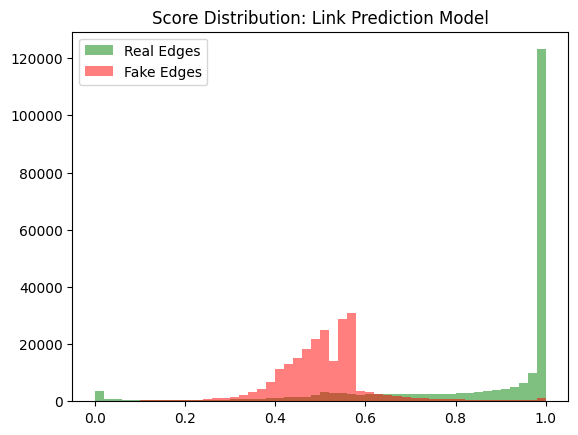

In [15]:
import matplotlib.pyplot as plt

# Get the predictions from the evaluation function
y_true = test_data.edge_label.cpu().numpy()
y_pred = torch.sigmoid((z[test_data.edge_label_index[0]] * z[test_data.edge_label_index[1]]).sum(dim=-1)).detach().cpu().numpy()

plt.hist(y_pred[y_true == 1], bins=50, alpha=0.5, label='Real Edges', color='green')
plt.hist(y_pred[y_true == 0], bins=50, alpha=0.5, label='Fake Edges', color='red')
plt.title("Score Distribution: Link Prediction Model")
plt.legend()
plt.show()

In [16]:
# 1. Get predictions on the test set
z = model(test_data.x, test_data.edge_index)
logits = (z[test_data.edge_label_index[0]] * z[test_data.edge_label_index[1]]).sum(dim=-1)
scores = torch.sigmoid(logits).detach().cpu().numpy()
y_true = test_data.edge_label.detach().cpu().numpy()

# 2. Identify False Positives: Score is high, but Label is 0
threshold = 0.8
fp_mask = (scores > threshold) & (y_true == 0)
fp_indices = test_data.edge_label_index[:, fp_mask]
fp_scores = scores[fp_mask]

# 3. Map back to usernames (reverse node_mapping)
inv_map = {v: k for k, v in node_mapping.items()}

fp_list = []
for i in range(fp_indices.shape[1]):
    u, v = fp_indices[0, i].item(), fp_indices[1, i].item()
    fp_list.append({
        'user_a': inv_map[u],
        'user_b': inv_map[v],
        'score': fp_scores[i]
    })

fp_df = pd.DataFrame(fp_list)
print(f"Found {len(fp_df)} high-confidence False Positives.")

Found 5971 high-confidence False Positives.


In [17]:
# Possible future work
# see if fp_df comes true later to further evaluate the gnn

,user_a,user_b,score
0,iaprrpai,micki5166,0.884822
1,ThEUnderDogE69,Thearizonaguy92,0.873861
2,GraceFullove,Adventurous_Try2250,0.861174
3,affinityboi,hbomba_,0.800036
4,Confident_Leather_98,No-Box4296,0.906631
...,...,...,...
5966,bo0ya,Dread5050,0.826675
5967,WeirdBoi12408,TheRealBugTastic,0.958166
5968,EhintheBay,avsteele34,0.852445
5969,matrixfox221,Nojodaspirra,0.857659
